<a href="https://colab.research.google.com/github/pras1978/fitness-journey-analyzer/blob/main/notebooks/05_progress_forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1 — Install prophet

In [1]:
!pip install prophet

Step 2 — Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

Step 3 — Load fitness dataset

In [9]:
import os

ts_path = "/content/drive/MyDrive/fitness-journey-analyzer/data/timeseries/fitness_tracking"

print(os.listdir(ts_path))

['fitness_data.csv', '.ipynb_checkpoints']


In [11]:
file = "/content/drive/MyDrive/fitness-journey-analyzer/data/timeseries/fitness_tracking/fitness_data.csv"

import pandas as pd
df = pd.read_csv(file)

df.head()

,User_ID,Full Name,Date,Age,Gender,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Workout_Type,Stress_Level (1-10),Mood
0,1,Sara Martinez,2023-01-01 00:00:00,19,Female,191,80,11405,1862,7.021201,3.440508,80.0,84.0,Yoga,2,Happy
1,1,Sara Martinez,2023-01-02 00:00:00,19,Female,191,80,7010,1806,NaN,3.103590,47.0,72.0,Cardio,9,Neutral
2,1,Sara Martinez,2023-01-03 00:00:00,19,Female,191,80,18942,2274,8.167817,3.814843,46.0,85.0,Yoga,6,Sad
3,1,Sara Martinez,2023-01-04 00:00:00,19,Female,191,80,13778,2656,7.453552,3.508636,105.0,77.0,Yoga,2,Sad
4,1,Sara Martinez,2023-01-05 00:00:00,19,Female,191,80,10247,3571,5.132654,NaN,53.0,61.0,Yoga,8,Sad


Step 4 — Check dataset columns

In [14]:
print(df.shape)
print(df.columns)

(36500, 16)
Index(['User_ID', 'Full Name', 'Date', 'Age', 'Gender', 'Height (cm)',
       'Weight (kg)', 'Steps_Taken', 'Calories_Burned', 'Hours_Slept',
       'Water_Intake (Liters)', 'Active_Minutes', 'Heart_Rate (bpm)',
       'Workout_Type', 'Stress_Level (1-10)', 'Mood'],
      dtype='object')


Step 5 — Convert date column

In [18]:
df["Date"] = pd.to_datetime(df["Date"])

In [27]:
df = df.sort_values("Date")

Step 6 — Prepare data for Prophet

In [28]:
df_prophet = df[["Date","Weight (kg)"]]

df_prophet = df_prophet.rename(columns={
    "Date":"ds",
    "Weight (kg)":"y"
})

df_prophet.head()

,ds,y
0,2023-01-01,80
23725,2023-01-01,75
1095,2023-01-01,95
6205,2023-01-01,107
32485,2023-01-01,56


Step 7 — Train forecasting model

In [29]:
from prophet import Prophet

model = Prophet()

model.fit(df_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Step 8 — Predict next 30 days

In [30]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-01-01,85.669923,57.178339,111.682436,85.669923,85.669923,0.001483,0.001483,0.001483,0.001483,0.001483,0.001483,0.0,0.0,0.0,85.671407
1,2023-01-02,85.683675,58.720399,113.269981,85.683675,85.683675,0.001016,0.001016,0.001016,0.001016,0.001016,0.001016,0.0,0.0,0.0,85.684691
2,2023-01-03,85.697427,58.388667,112.933853,85.697427,85.697427,0.000460,0.000460,0.000460,0.000460,0.000460,0.000460,0.0,0.0,0.0,85.697887
3,2023-01-04,85.711179,58.754859,113.804444,85.711179,85.711179,-0.000096,-0.000096,-0.000096,-0.000096,-0.000096,-0.000096,0.0,0.0,0.0,85.711083
4,2023-01-05,85.724931,58.051794,111.516915,85.724931,85.724931,-0.000652,-0.000652,-0.000652,-0.000652,-0.000652,-0.000652,0.0,0.0,0.0,85.724279


Step 9 — Plot prediction

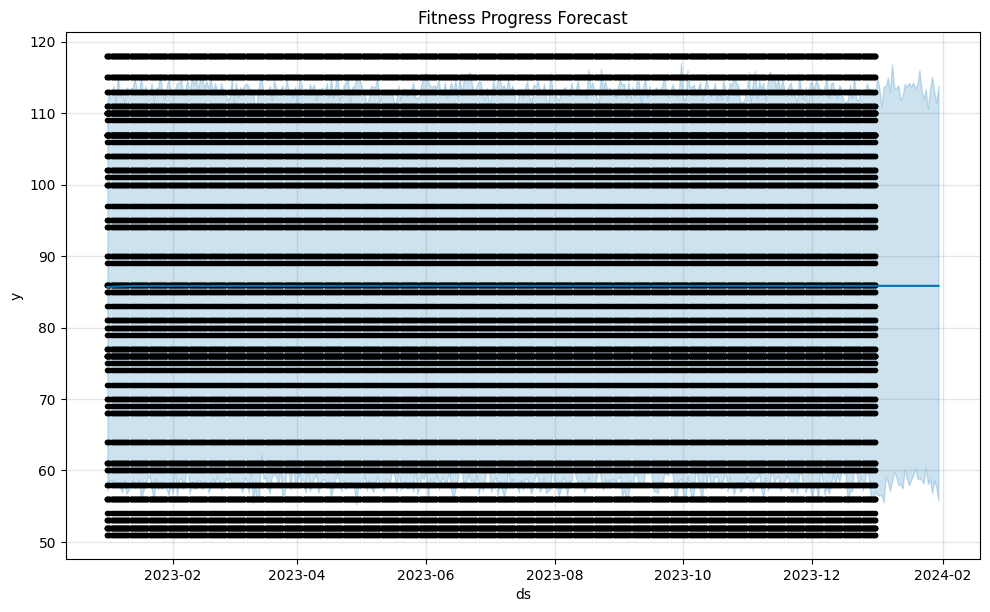

In [31]:
import matplotlib.pyplot as plt

model.plot(forecast)
plt.title("Fitness Progress Forecast")
plt.show()

Step 10 — Show trend and seasonality

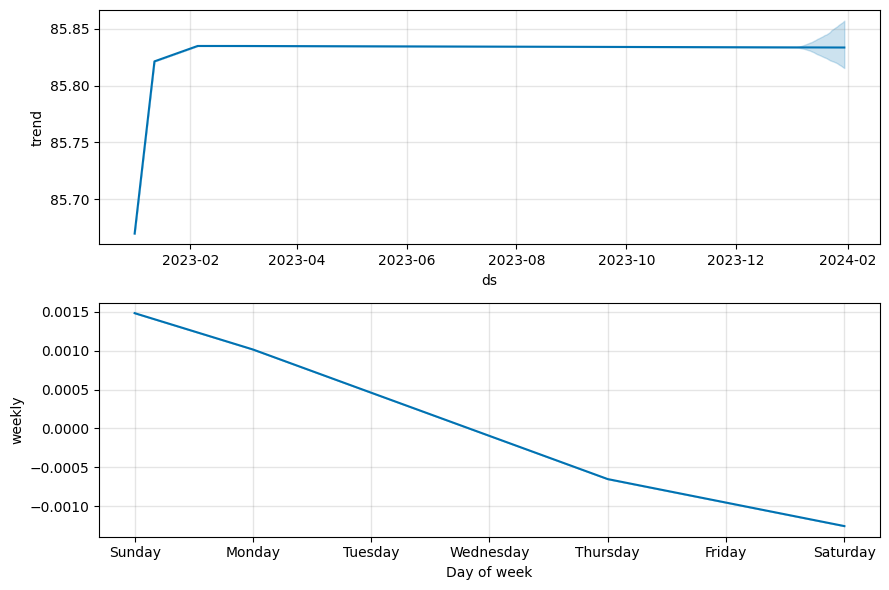

In [32]:
model.plot_components(forecast)
plt.show()

Step 11 — Save predictions

In [33]:
output_path = "/content/drive/MyDrive/fitness-journey-analyzer/data/processed/fitness_forecast.csv"

forecast.to_csv(output_path, index=False)

print("Forecast saved to:", output_path)

Forecast saved to: /content/drive/MyDrive/fitness-journey-analyzer/data/processed/fitness_forecast.csv


In [26]:
print(df.columns)

Index(['User_ID', 'Full Name', 'Date', 'Age', 'Gender', 'Height (cm)',
       'Weight (kg)', 'Steps_Taken', 'Calories_Burned', 'Hours_Slept',
       'Water_Intake (Liters)', 'Active_Minutes', 'Heart_Rate (bpm)',
       'Workout_Type', 'Stress_Level (1-10)', 'Mood'],
      dtype='object')
